# 第11回：実現可能集合と交渉領域の可視化

`11_barganing_game.md` の「具体例：収益分配の交渉」と演習1について，実現可能集合と交渉領域を2次元平面に描く．

- 横軸：Aの利得 $u_A$
- 縦軸：Bの利得 $u_B$
- 青色：実現可能集合 $U$
- 緑色：交渉領域
- 星印：交渉の不一致点 $d$

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Polygon

# 利用可能な日本語フォントを選ぶ．
preferred_fonts = [
    "Hiragino Sans",
    "Yu Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False


def classify_allocation(point, total, disagreement):
    """利得ベクトルが実現可能集合・交渉領域のどこにあるかを返す．"""
    u_a, u_b = point
    d_a, d_b = disagreement
    feasible = u_a >= 0 and u_b >= 0 and u_a + u_b <= total
    acceptable = u_a >= d_a and u_b >= d_b

    if feasible and acceptable:
        return "交渉領域内"
    if feasible:
        return "実現可能だが交渉領域外"
    return "実現不可能"


def plot_bargaining_problem(ax, total, disagreement, title, candidates=None):
    """総額と不一致点から実現可能集合と交渉領域を描く．"""
    d_a, d_b = disagreement
    if d_a < 0 or d_b < 0 or d_a + d_b > total:
        raise ValueError("不一致点は実現可能集合の中に置いてください．")

    feasible_vertices = [(0, 0), (total, 0), (0, total)]
    bargaining_vertices = [
        (d_a, d_b),
        (total - d_b, d_b),
        (d_a, total - d_a),
    ]

    feasible_region = Polygon(
        feasible_vertices,
        closed=True,
        facecolor="#4C78A8",
        edgecolor="#1F4E79",
        alpha=0.28,
        linewidth=2,
        label="実現可能集合 $U$",
    )
    bargaining_region = Polygon(
        bargaining_vertices,
        closed=True,
        facecolor="#59A14F",
        edgecolor="#2F6B2A",
        alpha=0.55,
        linewidth=2,
        label="交渉領域",
    )
    ax.add_patch(feasible_region)
    ax.add_patch(bargaining_region)

    ax.plot(
        [0, total],
        [total, 0],
        color="#1F1F1F",
        linewidth=2,
        label=r"パレート最適な境界 $u_A+u_B=100$",
    )
    ax.axvline(d_a, color="#2F6B2A", linestyle="--", linewidth=1)
    ax.axhline(d_b, color="#2F6B2A", linestyle="--", linewidth=1)
    ax.scatter(
        [d_a],
        [d_b],
        marker="*",
        s=220,
        color="#E15759",
        edgecolor="black",
        linewidth=0.7,
        zorder=5,
        label=f"不一致点 $d=({d_a},{d_b})$",
    )

    if candidates:
        colors = {
            "交渉領域内": "#006D2C",
            "実現可能だが交渉領域外": "#FF8C00",
            "実現不可能": "#B22222",
        }
        markers = {
            "交渉領域内": "o",
            "実現可能だが交渉領域外": "s",
            "実現不可能": "X",
        }
        for point in candidates:
            status = classify_allocation(point, total, disagreement)
            u_a, u_b = point
            ax.scatter(
                [u_a],
                [u_b],
                s=90,
                color=colors[status],
                marker=markers[status],
                edgecolor="black",
                linewidth=0.6,
                zorder=6,
                label=f"{point}: {status}",
            )
            ax.annotate(
                str(point),
                (u_a, u_b),
                xytext=(5, 7),
                textcoords="offset points",
                fontsize=9,
            )

    upper = total + 15 if candidates else total + 5
    ax.set_xlim(-5, upper)
    ax.set_ylim(-5, upper)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"Aの利得 $u_A$（万円）")
    ax.set_ylabel(r"Bの利得 $u_B$（万円）")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.95)


## 具体例：収益分配の交渉

実現可能集合は

$$
U=\{(u_A,u_B)\mid u_A+u_B\leq 100,\ u_A\geq 0,\ u_B\geq 0\}
$$

である．不一致点が $d=(0,0)$ の場合と $d=(50,20)$ の場合を比較する．

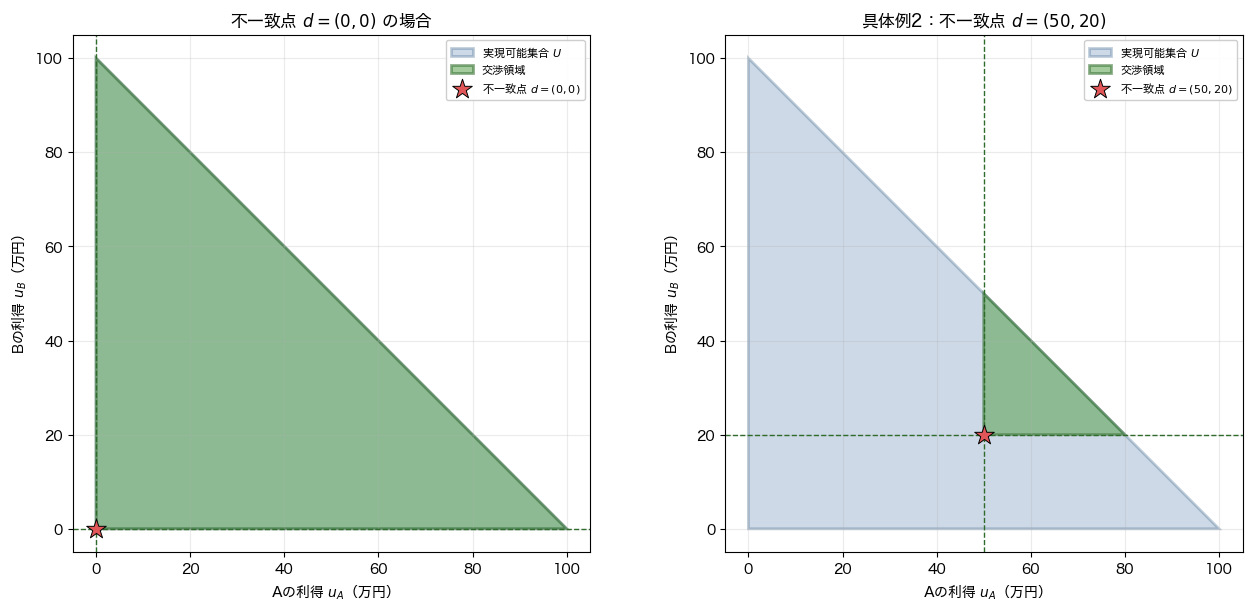

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

plot_bargaining_problem(
    axes[0],
    total=100,
    disagreement=(0, 0),
    title="不一致点 $d=(0,0)$ の場合",
)
plot_bargaining_problem(
    axes[1],
    total=100,
    disagreement=(50, 20),
    title="具体例2：不一致点 $d=(50,20)$",
)

plt.show()


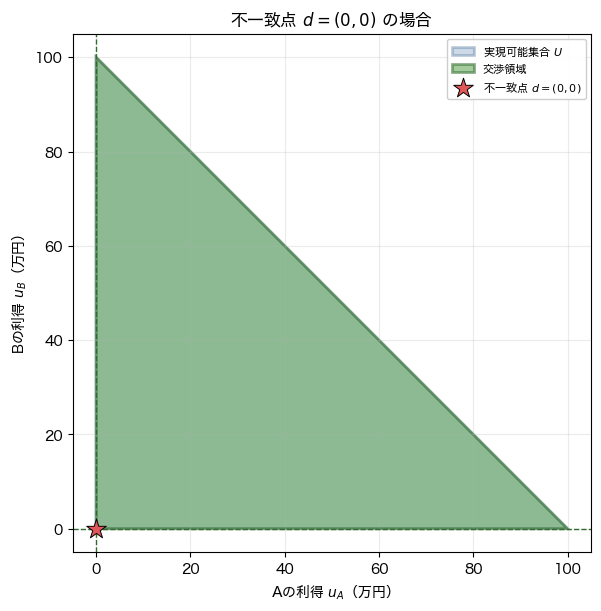

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True)

plot_bargaining_problem(
    axes,
    total=100,
    disagreement=(0, 0),
    title="不一致点 $d=(0,0)$ の場合",
)
plt.show()
# fig.savefig("../figs/11/1.png")

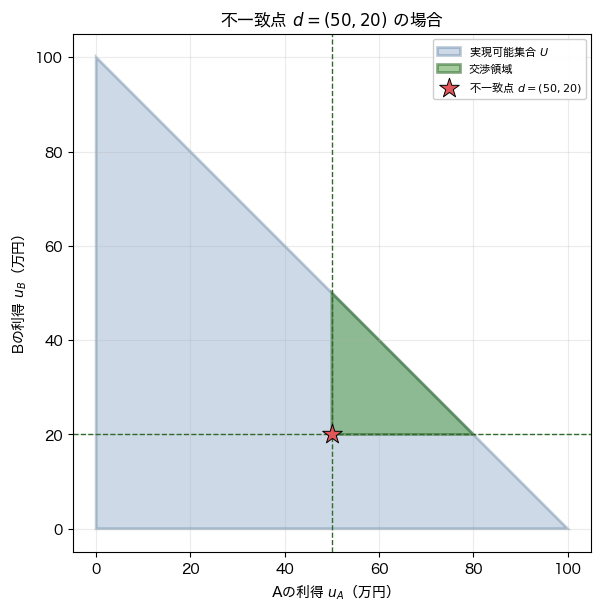

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True)

plot_bargaining_problem(
    axes,
    total=100,
    disagreement=(50, 20),
    title="不一致点 $d=(50,20)$ の場合",
)
plt.show()
# fig.savefig("../figs/11/ex1.png")

## 演習1：収益分配の交渉

演習では不一致点が $d=(30,10)$ である．したがって，交渉領域は

$$
\{(u_A,u_B)\mid u_A+u_B\leq 100,\ u_A\geq 30,\ u_B\geq 10\}
$$

となる．候補点 $(40,50)$，$(20,70)$，$(80,30)$ も同じ平面に表示する．

In [ ]:
exercise_points = [(40, 50), (20, 70), (80, 30)]

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
plot_bargaining_problem(
    ax,
    total=100,
    disagreement=(30, 10),
    title="演習1：実現可能集合と交渉領域",
    candidates=exercise_points,
)
plt.show()

for point in exercise_points:
    status = classify_allocation(point, total=100, disagreement=(30, 10))
    print(f"{point}: {status}")


# テスト


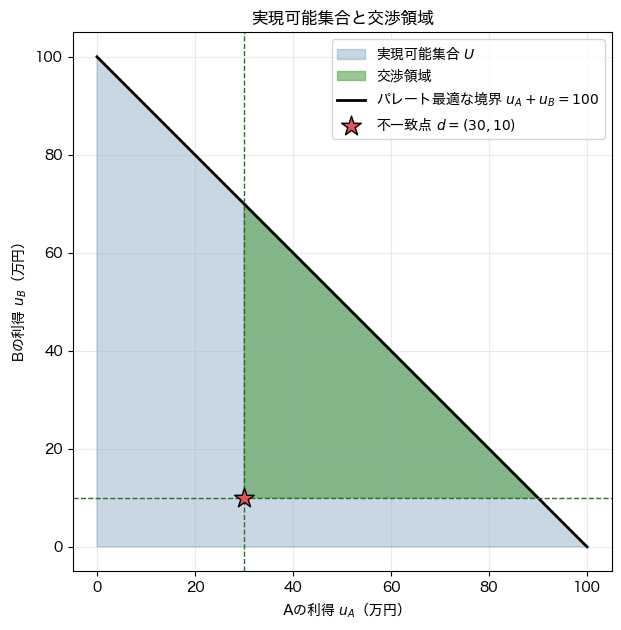

In [16]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 利用可能な日本語フォントを選ぶ
preferred_fonts = [
    "Hiragino Sans",
    "Yu Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False

# 交渉問題の設定
total = 100
d_a, d_b = 30, 10

# 実現可能集合の3頂点
feasible_x = [0, total, 0]
feasible_y = [0, 0, total]

# 交渉領域の3頂点
bargaining_x = [d_a, total - d_b, d_a]
bargaining_y = [d_b, d_b, total - d_a]

fig, ax = plt.subplots(figsize=(7, 7))

ax.fill(
    feasible_x,
    feasible_y,
    color="#4C78A8",
    alpha=0.30,
    label="実現可能集合 $U$",
)
ax.fill(
    bargaining_x,
    bargaining_y,
    color="#59A14F",
    alpha=0.60,
    label="交渉領域",
)

# パレート最適な境界と不一致点を描く
ax.plot(
    [0, total],
    [total, 0],
    color="black",
    linewidth=2,
    label=r"パレート最適な境界 $u_A+u_B=100$",
)
ax.axvline(d_a, color="#2F6B2A", linestyle="--", linewidth=1)
ax.axhline(d_b, color="#2F6B2A", linestyle="--", linewidth=1)
ax.scatter(
    d_a,
    d_b,
    marker="*",
    s=220,
    color="#E15759",
    edgecolor="black",
    label=fr"不一致点 $d=({d_a},{d_b})$",
    zorder=3,
)

ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.set_aspect("equal")
ax.set_xlabel(r"Aの利得 $u_A$（万円）")
ax.set_ylabel(r"Bの利得 $u_B$（万円）")
ax.set_title("実現可能集合と交渉領域")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

plt.show()